# Sofia ML Regression 2026 — Exploratory Data Analysis

Visualizing patterns in the training and test data to inform feature engineering and model choice.

Key facts discovered upfront:
- **2500 train / 2500 test** samples, 15 anonymous features (`x0`–`x14`)
- Target is **extremely heavy-tailed** (skewness ≈ 13.6, kurtosis ≈ 708) — most values cluster near zero, but outliers reach ±40 000
- Features are nearly **uncorrelated with each other** (max pairwise r ≈ 0.06)
- `x9` is the only feature with meaningful linear signal (r ≈ 0.23 with target)
- Every feature has ~1–2% missing values scattered across both sets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
BLUE, ORANGE, RED, GRAY = "#4C72B0", "#DD8452", "#C44E52", "#8C8C8C"

train = pd.read_csv("spring2026_kaggle_linear_regression_challenge_train.csv")
test  = pd.read_csv("spring2026_kaggle_linear_regression_challenge_test.csv")

features = [c for c in train.columns if c.startswith("x")]
X = train[features]
y = train["target"]
X_test = test[features]

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Target  mean={y.mean():.1f}  median={y.median():.2f}  std={y.std():.1f}  skew={y.skew():.2f}")

Train: (2500, 17)  |  Test: (2500, 16)
Target  mean=-22.0  median=-0.77  std=1978.2  skew=13.59


## 1 · Target Distribution — Bulk vs Tails

The target has extreme outliers that dwarf the bulk of the data. A single histogram hides both stories. Here we show them side-by-side: the full range and a zoomed core (±300), plus a Q-Q plot to quantify how far the tails deviate from a normal distribution.

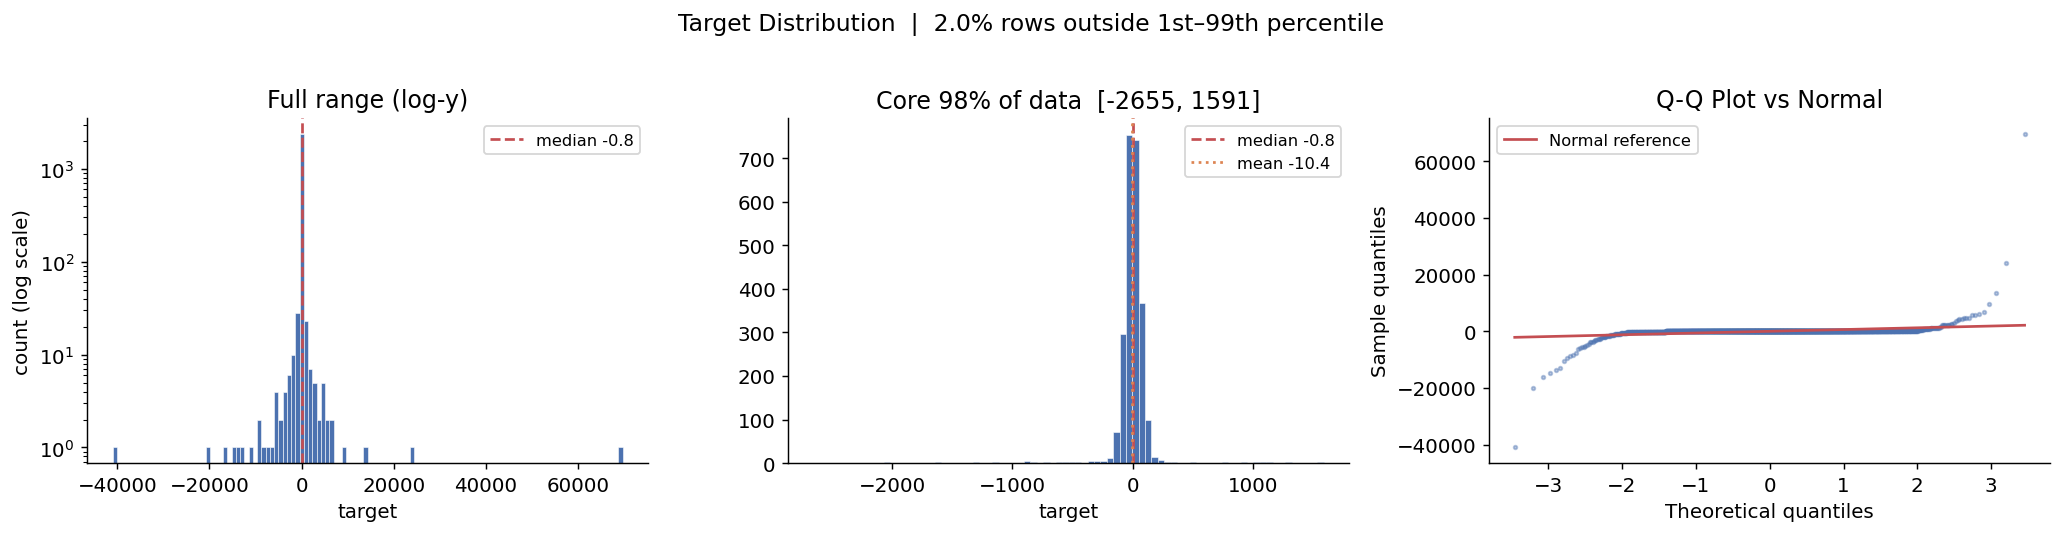

Skewness: 13.59   Kurtosis: 708
Rows with |target| > 1 000: 84  (3.4%)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- full range (log-scale y to show outlier bars) ---
ax = axes[0]
ax.hist(y, bins=120, color=BLUE, edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("target")
ax.set_ylabel("count (log scale)")
ax.set_title("Full range (log-y)")
ax.axvline(y.median(), color=RED, lw=1.5, linestyle="--", label=f"median {y.median():.1f}")
ax.legend(fontsize=9)

# --- zoomed bulk: drop top/bottom 1% ---
ax = axes[1]
lo, hi = y.quantile(0.01), y.quantile(0.99)
bulk = y[(y >= lo) & (y <= hi)]
ax.hist(bulk, bins=80, color=BLUE, edgecolor="white", linewidth=0.3)
ax.set_xlabel("target")
ax.set_title(f"Core 98% of data  [{lo:.0f}, {hi:.0f}]")
ax.axvline(bulk.median(), color=RED, lw=1.5, linestyle="--", label=f"median {bulk.median():.1f}")
ax.axvline(bulk.mean(),   color=ORANGE, lw=1.5, linestyle=":",  label=f"mean {bulk.mean():.1f}")
ax.legend(fontsize=9)

# --- Q-Q plot ---
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(y, dist="norm")
ax.scatter(osm, osr, s=4, alpha=0.4, color=BLUE)
ax.plot([osm[0], osm[-1]],
        [slope * osm[0] + intercept, slope * osm[-1] + intercept],
        color=RED, lw=1.5, label="Normal reference")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.set_title("Q-Q Plot vs Normal")
ax.legend(fontsize=9)

pct_outlier = ((y < lo) | (y > hi)).mean() * 100
fig.suptitle(f"Target Distribution  |  {pct_outlier:.1f}% rows outside 1st–99th percentile",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness: {y.skew():.2f}   Kurtosis: {y.kurtosis():.0f}")
print(f"Rows with |target| > 1 000: {(y.abs() > 1000).sum()}  ({(y.abs()>1000).mean()*100:.1f}%)")

## 2 · Missing Value Patterns

Each feature has ~1–2% missing values. The question is whether missingness is random (MCAR) or structured — e.g., do certain rows tend to be missing across many features simultaneously? A structured pattern would suggest the missing-ness itself carries signal.

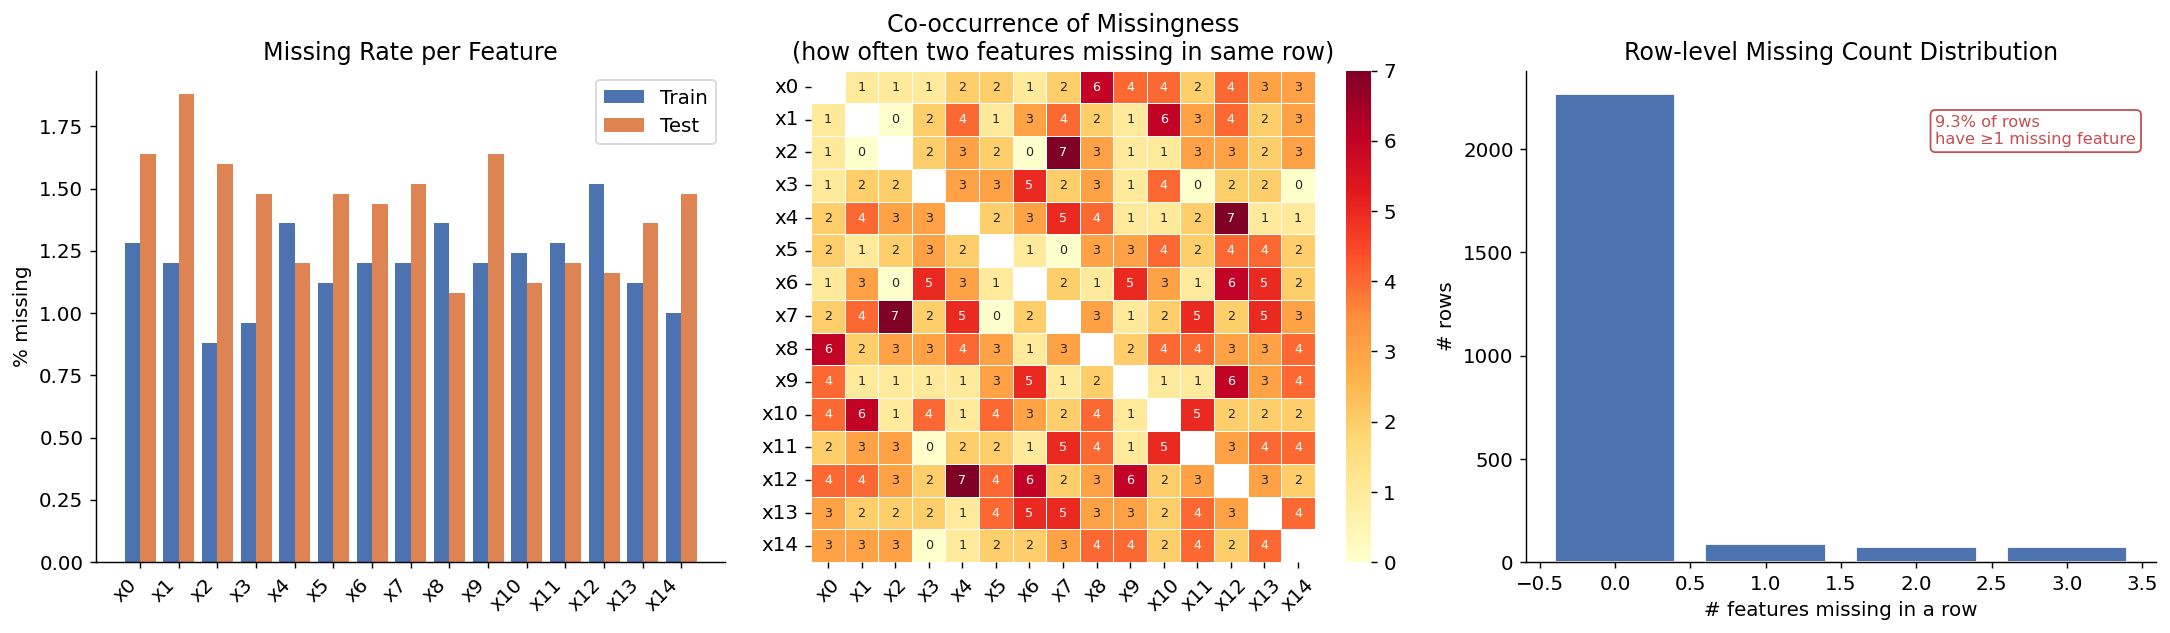

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- per-feature missing rate bar chart ---
ax = axes[0]
miss_train = X.isnull().mean() * 100
miss_test  = X_test.isnull().mean() * 100
x_pos = np.arange(len(features))
ax.bar(x_pos - 0.2, miss_train, width=0.4, label="Train", color=BLUE)
ax.bar(x_pos + 0.2, miss_test,  width=0.4, label="Test",  color=ORANGE)
ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("% missing")
ax.set_title("Missing Rate per Feature")
ax.legend()

# --- missing co-occurrence heatmap (train) ---
ax = axes[1]
miss_matrix = X.isnull().astype(int)
co_occur = miss_matrix.T.dot(miss_matrix)  # how often two features are jointly missing
mask = np.eye(len(features), dtype=bool)
sns.heatmap(co_occur, mask=mask, ax=ax, cmap="YlOrRd",
            xticklabels=features, yticklabels=features,
            linewidths=0.3, annot=True, fmt="d", annot_kws={"size": 7})
ax.set_title("Co-occurrence of Missingness\n(how often two features missing in same row)")
ax.tick_params(axis="x", rotation=45)

# --- distribution of missing-count per row ---
ax = axes[2]
row_miss = X.isnull().sum(axis=1)
counts = row_miss.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=BLUE, edgecolor="white")
ax.set_xlabel("# features missing in a row")
ax.set_ylabel("# rows")
ax.set_title("Row-level Missing Count Distribution")
pct_any = (row_miss > 0).mean() * 100
ax.text(0.65, 0.85, f"{pct_any:.1f}% of rows\nhave ≥1 missing feature",
        transform=ax.transAxes, fontsize=9, color=RED,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=RED))

plt.tight_layout()
plt.show()

## 3 · Train vs Test Feature Distributions (ECDF)

Before building a model, confirm the test set is drawn from the same distribution as training. Distribution shift means a model that fits training data well may not generalize. We use empirical CDFs (ECDFs) — they show the full shape without binning artifacts.

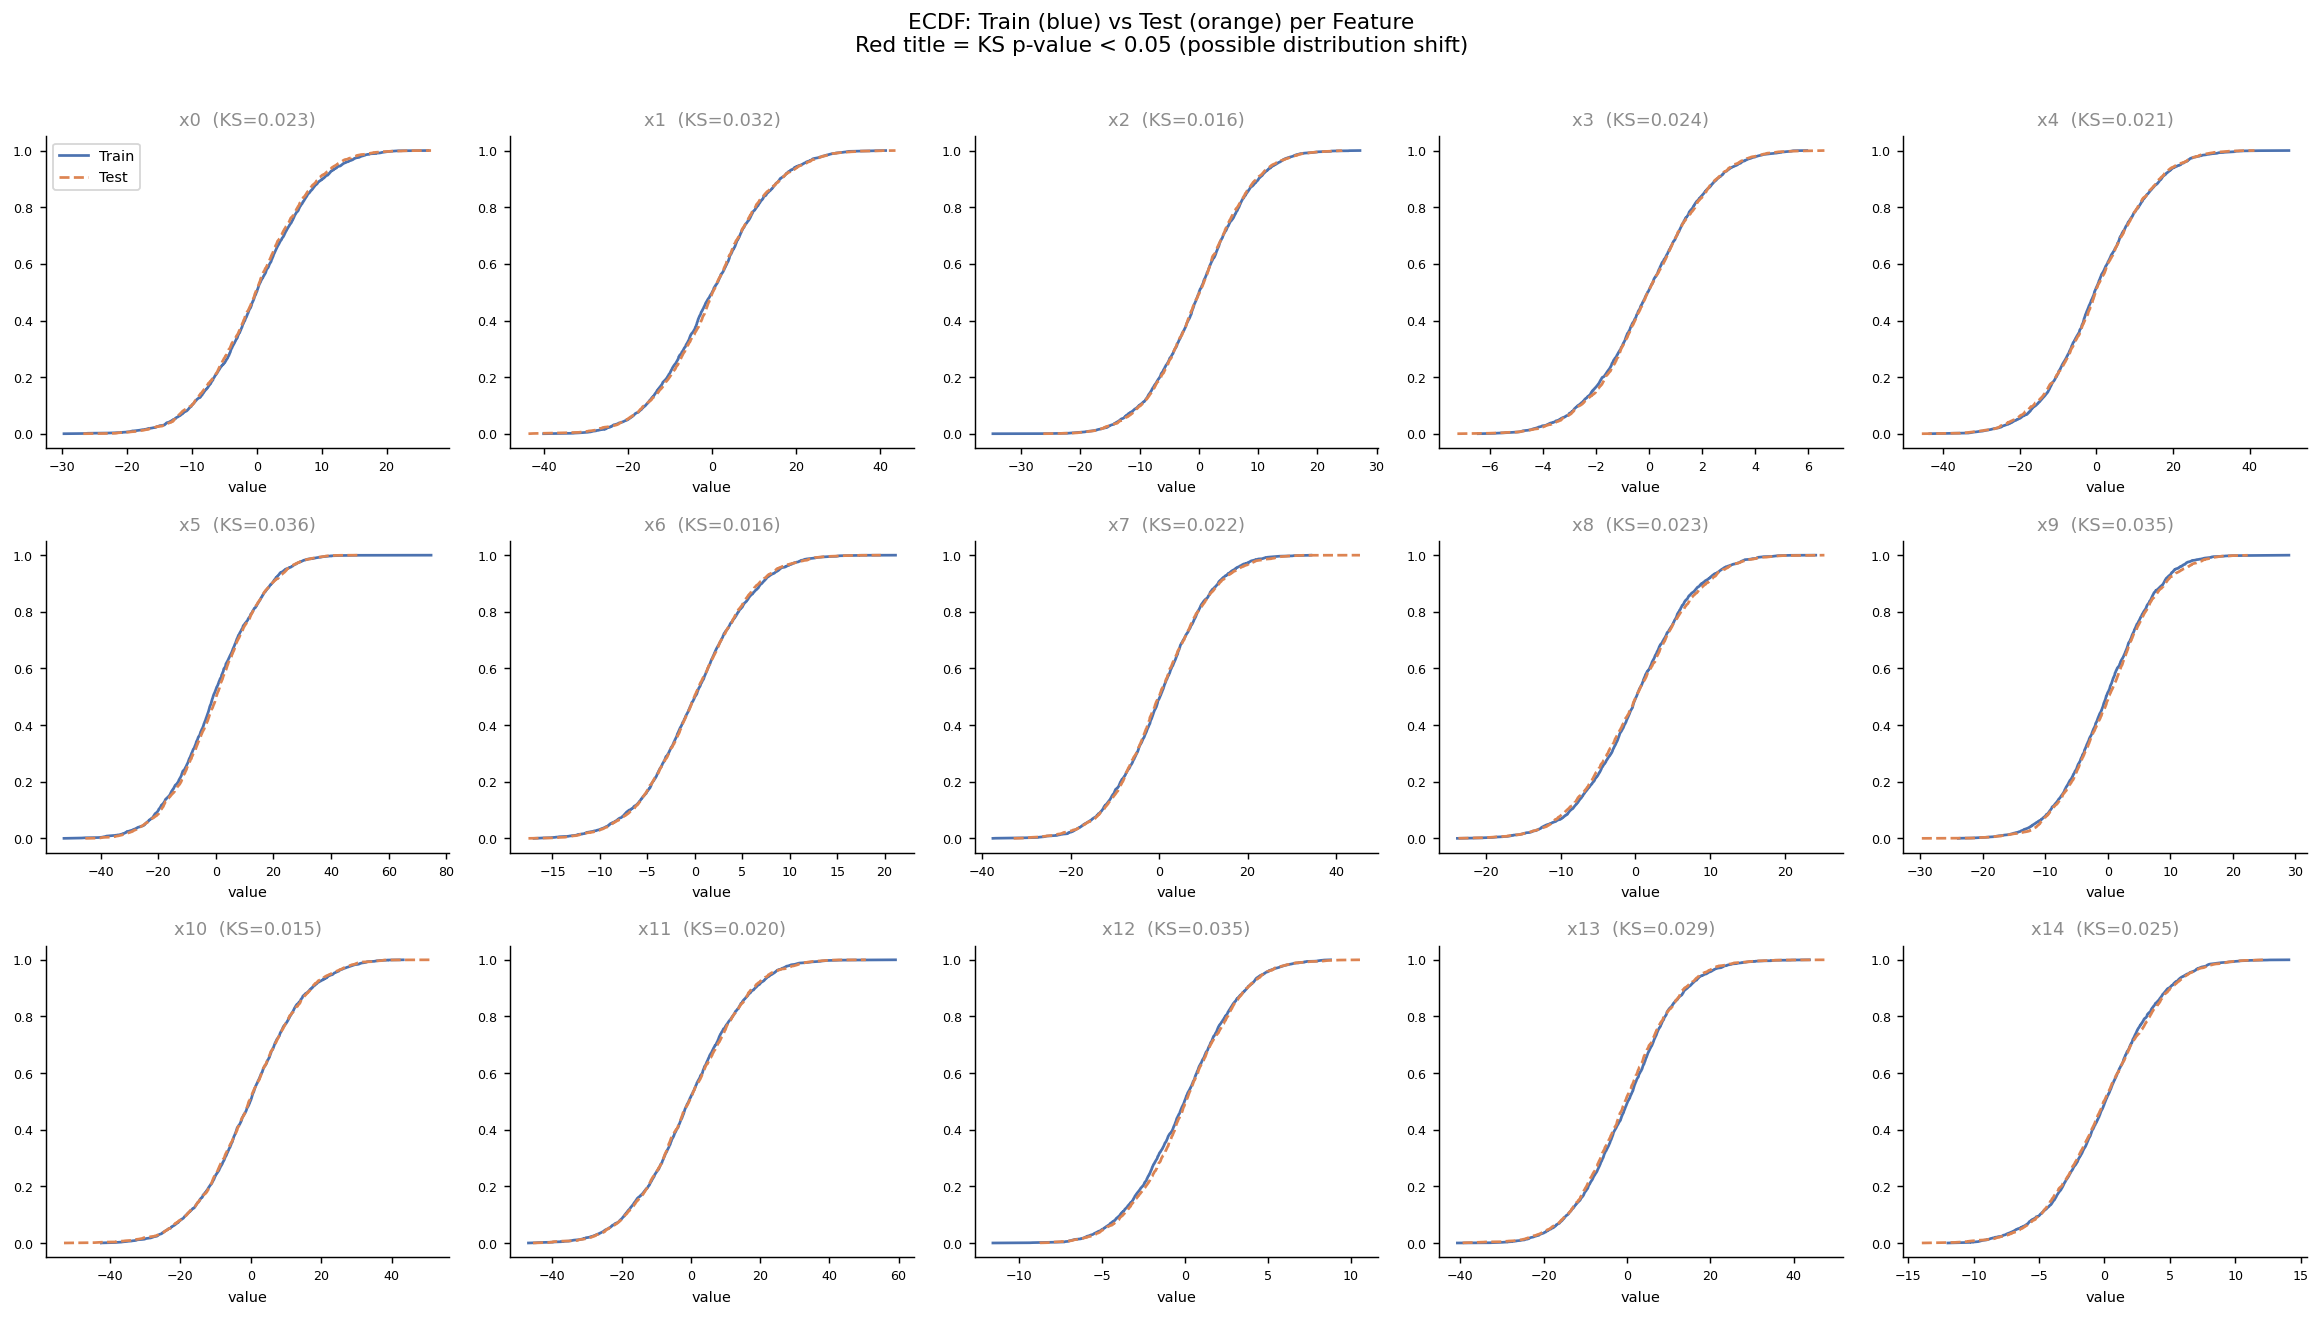

KS test results (stat, p-value):
  x0    KS=0.0225  p=0.5479
  x1    KS=0.0321  p=0.1536
  x2    KS=0.0162  p=0.8963
  x3    KS=0.0241  p=0.4582
  x4    KS=0.0206  p=0.6625
  x5    KS=0.0363  p=0.0747
  x6    KS=0.0155  p=0.9206
  x7    KS=0.0224  p=0.5526
  x8    KS=0.0234  p=0.4956
  x9    KS=0.0352  p=0.0916
  x10   KS=0.0152  p=0.9327
  x11   KS=0.0200  p=0.6940
  x12   KS=0.0346  p=0.1016
  x13   KS=0.0286  p=0.2567
  x14   KS=0.0250  p=0.4142


In [6]:
def ecdf(data):
    d = np.sort(data.dropna())
    return d, np.arange(1, len(d)+1) / len(d)

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
ks_results = {}

for ax, feat in zip(axes.flat, features):
    tr_x, tr_y = ecdf(X[feat])
    te_x, te_y = ecdf(X_test[feat])
    ax.plot(tr_x, tr_y, color=BLUE,   lw=1.5, label="Train")
    ax.plot(te_x, te_y, color=ORANGE, lw=1.5, linestyle="--", label="Test")
    ks_stat, ks_p = stats.ks_2samp(X[feat].dropna(), X_test[feat].dropna())
    ks_results[feat] = (ks_stat, ks_p)
    color = RED if ks_p < 0.05 else GRAY
    ax.set_title(f"{feat}  (KS={ks_stat:.3f})", color=color, fontsize=10)
    ax.set_xlabel("value", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=8)

fig.suptitle("ECDF: Train (blue) vs Test (orange) per Feature\n"
             "Red title = KS p-value < 0.05 (possible distribution shift)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("KS test results (stat, p-value):")
for f, (s, p) in ks_results.items():
    flag = " ← SHIFT?" if p < 0.05 else ""
    print(f"  {f:4s}  KS={s:.4f}  p={p:.4f}{flag}")

## 4 · Feature–Target Relationships: Normal vs Extreme Rows

Because individual linear correlations are weak, we look at scatter plots split by whether the target is "normal" (within the core 98%) or "extreme" (top/bottom 1%). If a feature separates these two groups, it likely drives the outlier behavior rather than the bulk signal.

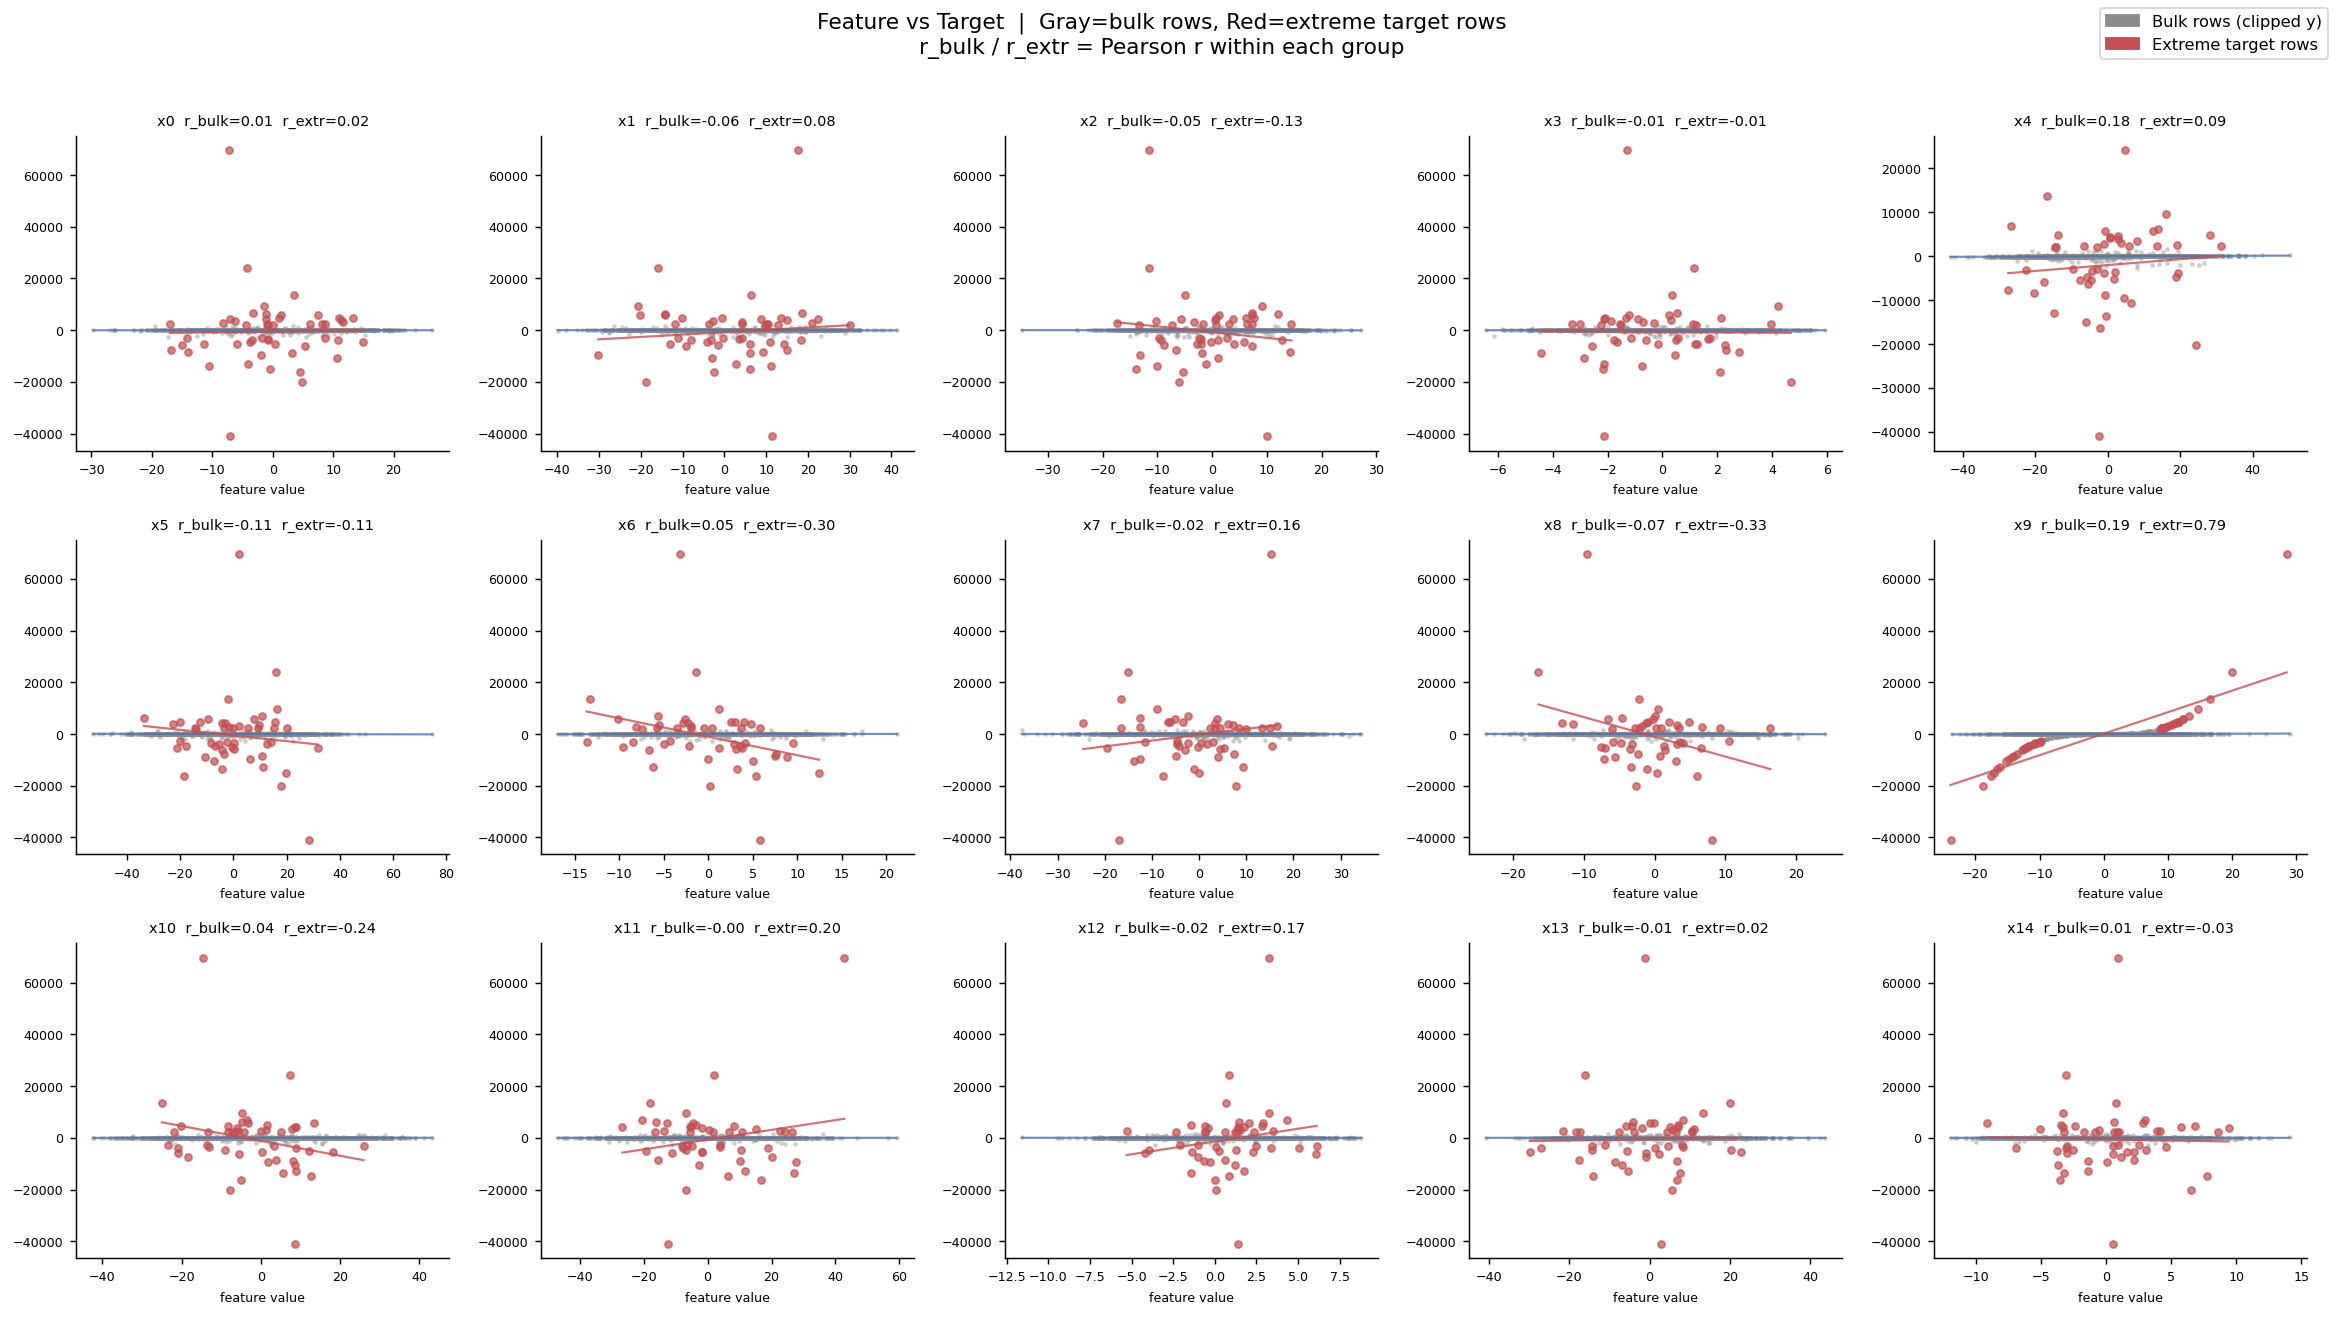

In [7]:
lo1, hi1 = y.quantile(0.01), y.quantile(0.99)
is_extreme = (y < lo1) | (y > hi1)
y_clipped  = y.clip(lo1, hi1)   # clip for visual clarity on bulk rows

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for ax, feat in zip(axes.flat, features):
    vals = X[feat]
    # bulk rows (gray, small, back layer)
    ax.scatter(vals[~is_extreme], y_clipped[~is_extreme],
               s=3, alpha=0.3, color=GRAY, rasterized=True)
    # extreme rows (red, prominent)
    ax.scatter(vals[is_extreme], y[is_extreme],
               s=15, alpha=0.7, color=RED, zorder=5)
    # linear fit line for each group
    for mask, col in [(~is_extreme, BLUE), (is_extreme, RED)]:
        xv = vals[mask].dropna()
        yv = y[mask].loc[xv.index]
        if len(xv) > 5:
            m, b, r, *_ = stats.linregress(xv, yv)
            xl = np.linspace(xv.min(), xv.max(), 50)
            ax.plot(xl, m * xl + b, color=col, lw=1.2, alpha=0.8)
    corr_bulk = vals[~is_extreme].corr(y[~is_extreme])
    corr_extr = vals[is_extreme].corr(y[is_extreme])
    ax.set_title(f"{feat}  r_bulk={corr_bulk:.2f}  r_extr={corr_extr:.2f}", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("feature value", fontsize=7)

patch_bulk  = mpatches.Patch(color=GRAY, label="Bulk rows (clipped y)")
patch_extr  = mpatches.Patch(color=RED,  label="Extreme target rows")
fig.legend(handles=[patch_bulk, patch_extr], loc="upper right", fontsize=9)
fig.suptitle("Feature vs Target  |  Gray=bulk rows, Red=extreme target rows\n"
             "r_bulk / r_extr = Pearson r within each group", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5 · Pairwise Interaction Heatmap (feature × feature → target correlation)

Individual features have weak linear signal (~0.23 max). But *products* of pairs can reveal interaction effects — e.g., `x3 * x9` might correlate strongly with target even if each alone doesn't. This heatmap computes Pearson r between every `xi * xj` product and the target.

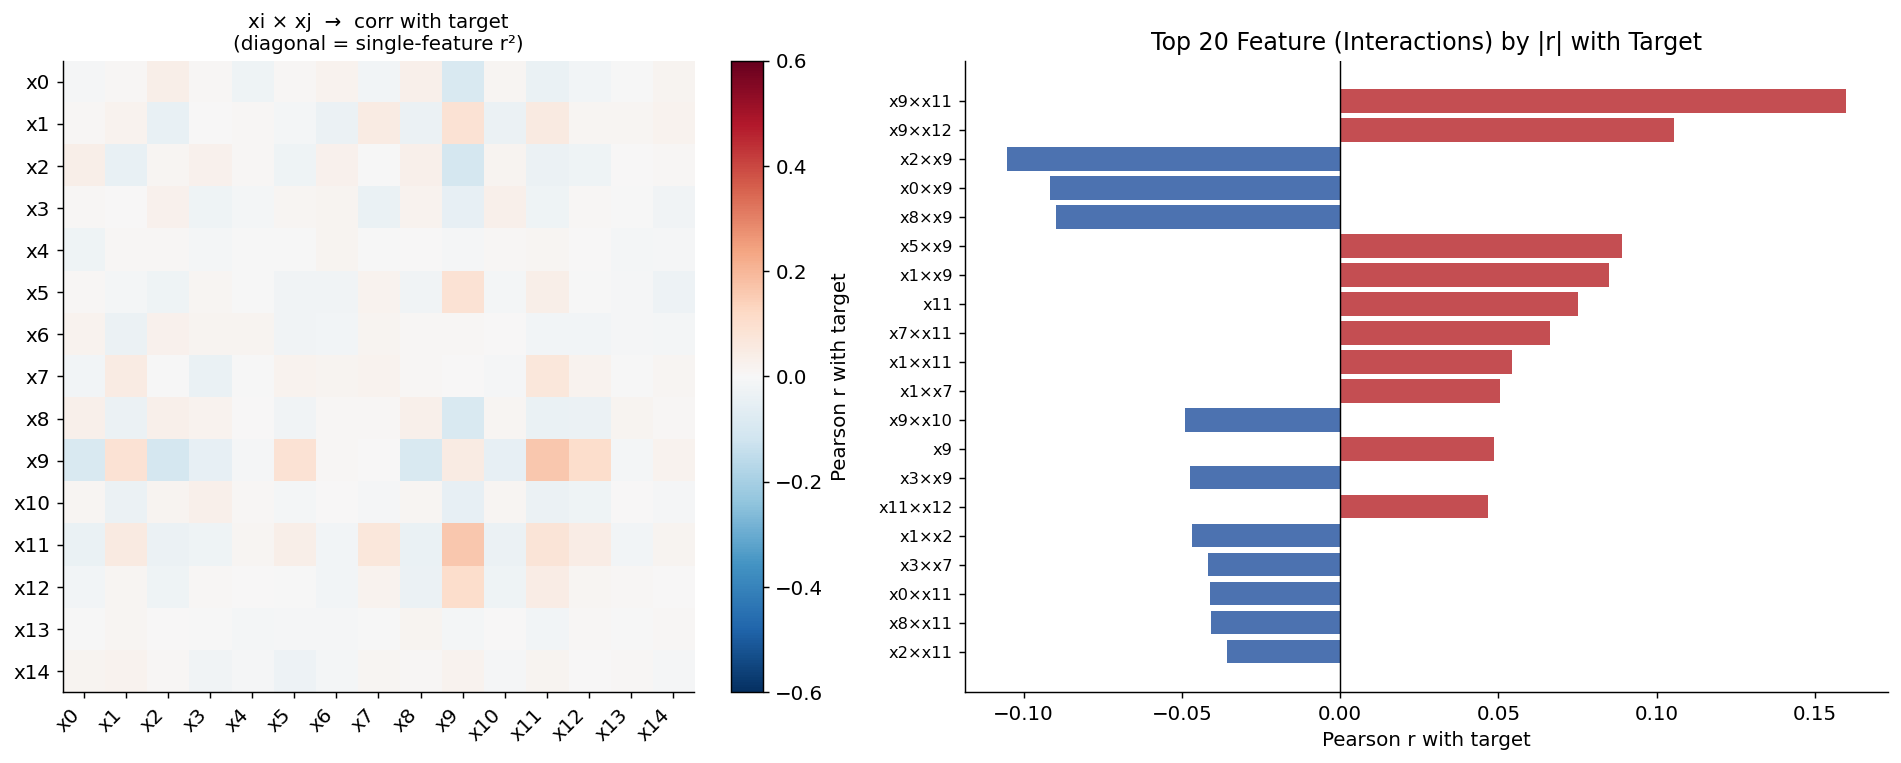

In [8]:
X_filled = X.fillna(X.median())

n = len(features)
interaction_corr = np.zeros((n, n))

for i, fi in enumerate(features):
    for j, fj in enumerate(features):
        product = X_filled[fi] * X_filled[fj]
        interaction_corr[i, j] = product.corr(y)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- full interaction heatmap ---
ax = axes[0]
im = ax.imshow(interaction_corr, cmap="RdBu_r", vmin=-0.6, vmax=0.6)
ax.set_xticks(range(n)); ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(features)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r with target")
ax.set_title("xi × xj  →  corr with target\n(diagonal = single-feature r²)", fontsize=11)
for i in range(n):
    for j in range(n):
        v = interaction_corr[i, j]
        if abs(v) > 0.25:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.4 else "black", fontweight="bold")

# --- top 20 interactions bar chart ---
ax = axes[1]
pairs, vals = [], []
for i, fi in enumerate(features):
    for j, fj in enumerate(features):
        if j >= i:
            label = f"{fi}×{fj}" if fi != fj else fi
            pairs.append(label)
            vals.append(interaction_corr[i, j])

top_idx = np.argsort(np.abs(vals))[-20:][::-1]
top_pairs_names = [pairs[k] for k in top_idx]
top_vals        = [vals[k]  for k in top_idx]
colors = [RED if v > 0 else BLUE for v in top_vals]
bars = ax.barh(range(len(top_vals)), top_vals, color=colors)
ax.set_yticks(range(len(top_vals)))
ax.set_yticklabels(top_pairs_names, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with target")
ax.set_title("Top 20 Feature (Interactions) by |r| with Target")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6 · PCA Feature Space — Colored by Target Magnitude

PCA reduces the 15 features to 2D so we can ask: do extreme-target rows live in a distinct region of feature space? If they cluster separately, the raw features contain enough structure to identify them. We also plot explained variance to see how much information the first few components carry.

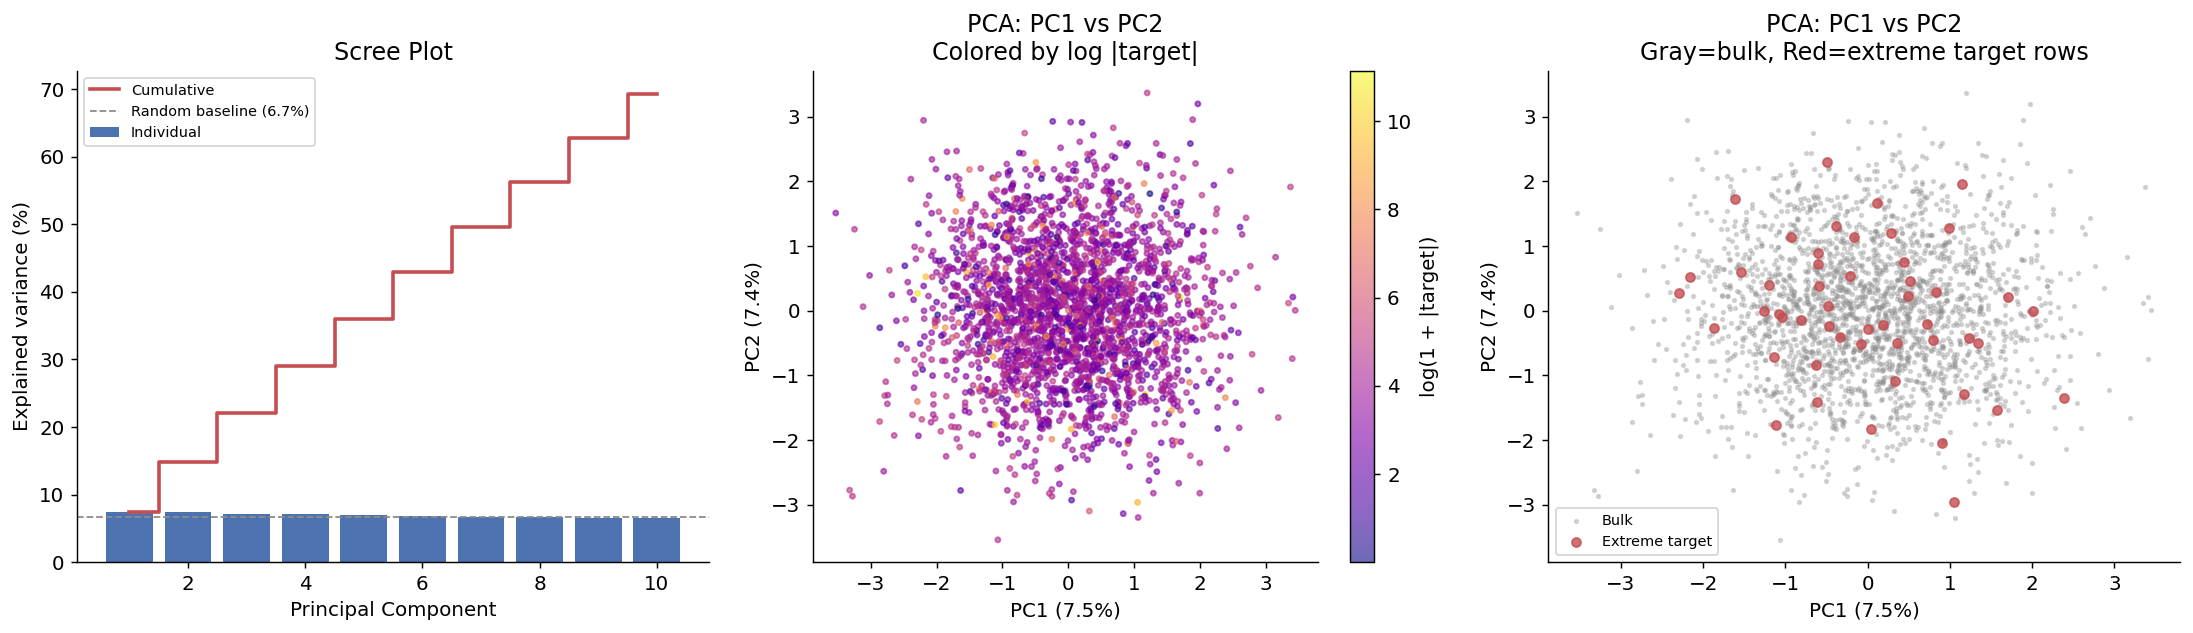

Cumulative variance explained — PC1-3: 22.0%  |  PC1-5: 36.0%  |  All 10: 69.3%


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_filled)

pca = PCA(n_components=10, random_state=42)
Z   = pca.fit_transform(X_sc)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- scree plot ---
ax = axes[0]
ev = pca.explained_variance_ratio_
cumev = np.cumsum(ev)
ax.bar(range(1, len(ev)+1), ev * 100, color=BLUE, label="Individual")
ax.step(range(1, len(ev)+1), cumev * 100, color=RED, where="mid", lw=2, label="Cumulative")
ax.axhline(100 / len(features), color=GRAY, linestyle="--", lw=1,
           label=f"Random baseline ({100/len(features):.1f}%)")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree Plot")
ax.legend(fontsize=8)

# --- PC1 vs PC2, colored by |target| ---
ax = axes[1]
y_mag = np.log1p(np.abs(y))   # log-magnitude for color scale
sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_mag, cmap="plasma",
                s=8, alpha=0.6, rasterized=True)
fig.colorbar(sc, ax=ax, label="log(1 + |target|)")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.set_title("PCA: PC1 vs PC2\nColored by log |target|")

# --- PC1 vs PC2, colored by extreme flag ---
ax = axes[2]
ax.scatter(Z[~is_extreme, 0], Z[~is_extreme, 1],
           s=4, alpha=0.3, color=GRAY, label="Bulk", rasterized=True)
ax.scatter(Z[is_extreme, 0], Z[is_extreme, 1],
           s=25, alpha=0.8, color=RED, label="Extreme target", zorder=5)
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.set_title("PCA: PC1 vs PC2\nGray=bulk, Red=extreme target rows")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Cumulative variance explained — PC1-3: {cumev[2]*100:.1f}%  |  PC1-5: {cumev[4]*100:.1f}%  |  All 10: {cumev[9]*100:.1f}%")

## 7 · Outlier Anatomy — Feature Profiles of Extreme Target Rows

For rows where |target| > 1000, what do the feature values look like? We compare the **standardized feature means** for extreme rows vs the rest. A spike in a feature means extreme-target rows tend to have unusually high or low values for that feature — a clue about what's driving the big predictions.

/var/folders/8f/2x6mf67944n7fgksx_8bk1400000gn/T/ipykernel_69418/2209667848.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features, rotation=45, ha="right")


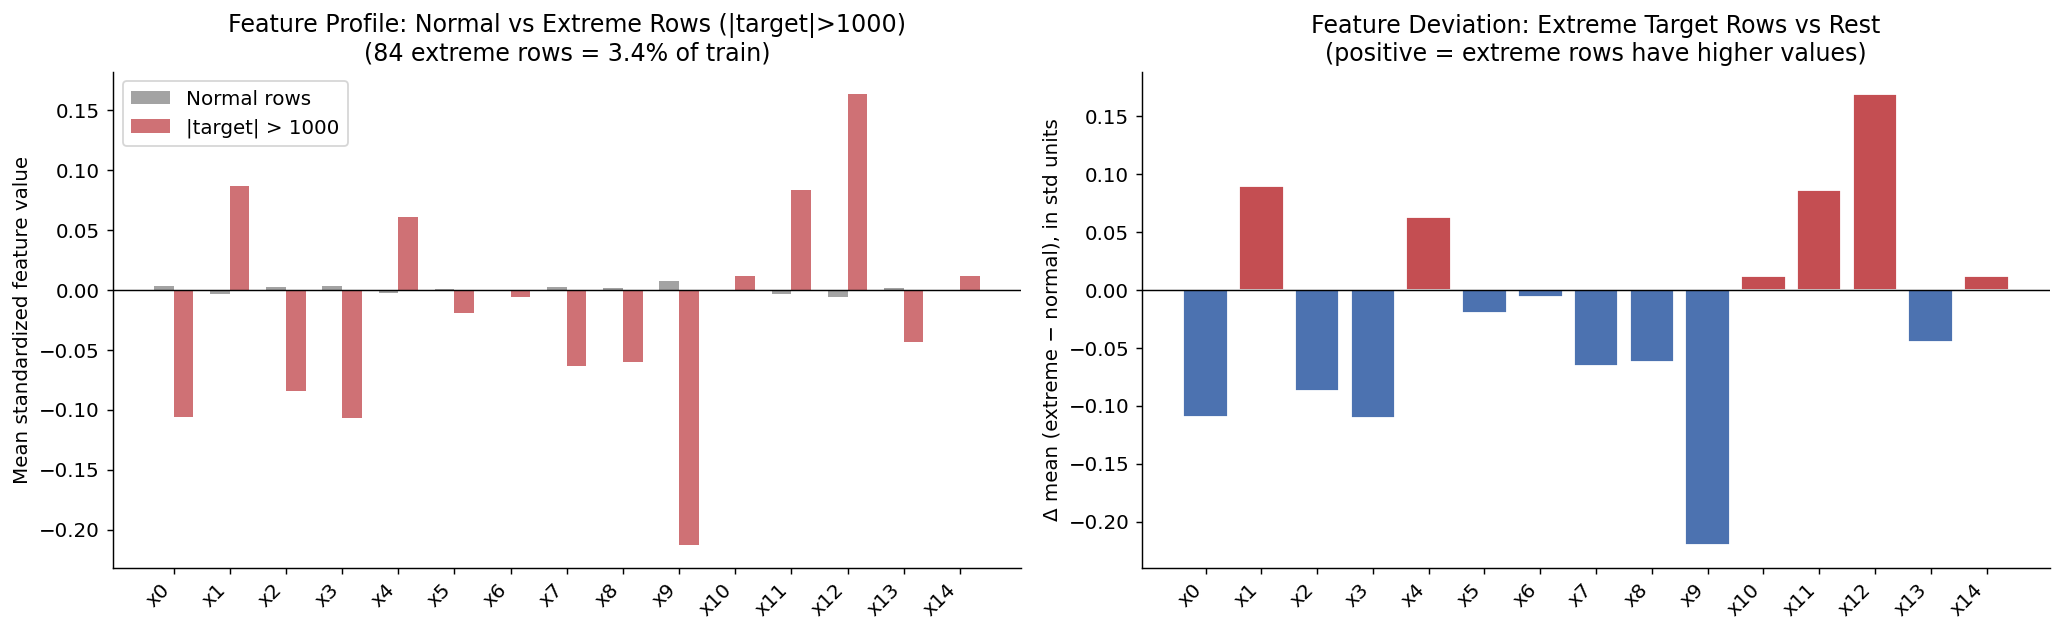

Rows with |target| > 1000: 84  (3.36%)

Top 5 features most different in extreme rows:
x9     0.220368
x12    0.169278
x3     0.110217
x0     0.109876
x1     0.089898


In [10]:
threshold = 1000
is_big = y.abs() > threshold

X_std = pd.DataFrame(X_sc, columns=features)

mean_big    = X_std[is_big.values].mean()
mean_normal = X_std[~is_big.values].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- radar / spider chart ---
ax = axes[0]
x_pos = np.arange(len(features))
width = 0.35
bars_n = ax.bar(x_pos - width/2, mean_normal, width, label="Normal rows", color=GRAY, alpha=0.8)
bars_b = ax.bar(x_pos + width/2, mean_big,    width, label=f"|target| > {threshold}", color=RED, alpha=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("Mean standardized feature value")
ax.set_title(f"Feature Profile: Normal vs Extreme Rows (|target|>{threshold})\n"
             f"({is_big.sum()} extreme rows = {is_big.mean()*100:.1f}% of train)")
ax.legend()

# --- difference (big - normal) ---
ax = axes[1]
diff = mean_big - mean_normal
colors = [RED if v > 0 else BLUE for v in diff]
ax.bar(features, diff, color=colors, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("Δ mean (extreme − normal), in std units")
ax.set_title("Feature Deviation: Extreme Target Rows vs Rest\n(positive = extreme rows have higher values)")

plt.tight_layout()
plt.show()

print(f"Rows with |target| > {threshold}: {is_big.sum()}  ({is_big.mean()*100:.2f}%)")
print("\nTop 5 features most different in extreme rows:")
print(diff.abs().sort_values(ascending=False).head(5).to_string())

## 8 · x9 Deep Dive — The Strongest Single Feature

`x9` has r ≈ 0.23 with target — easily the strongest single-feature signal. Here we zoom in: marginal distributions, scatter with a LOWESS smoother to catch non-linearity, and a conditional median plot (how does median target change as x9 increases?).

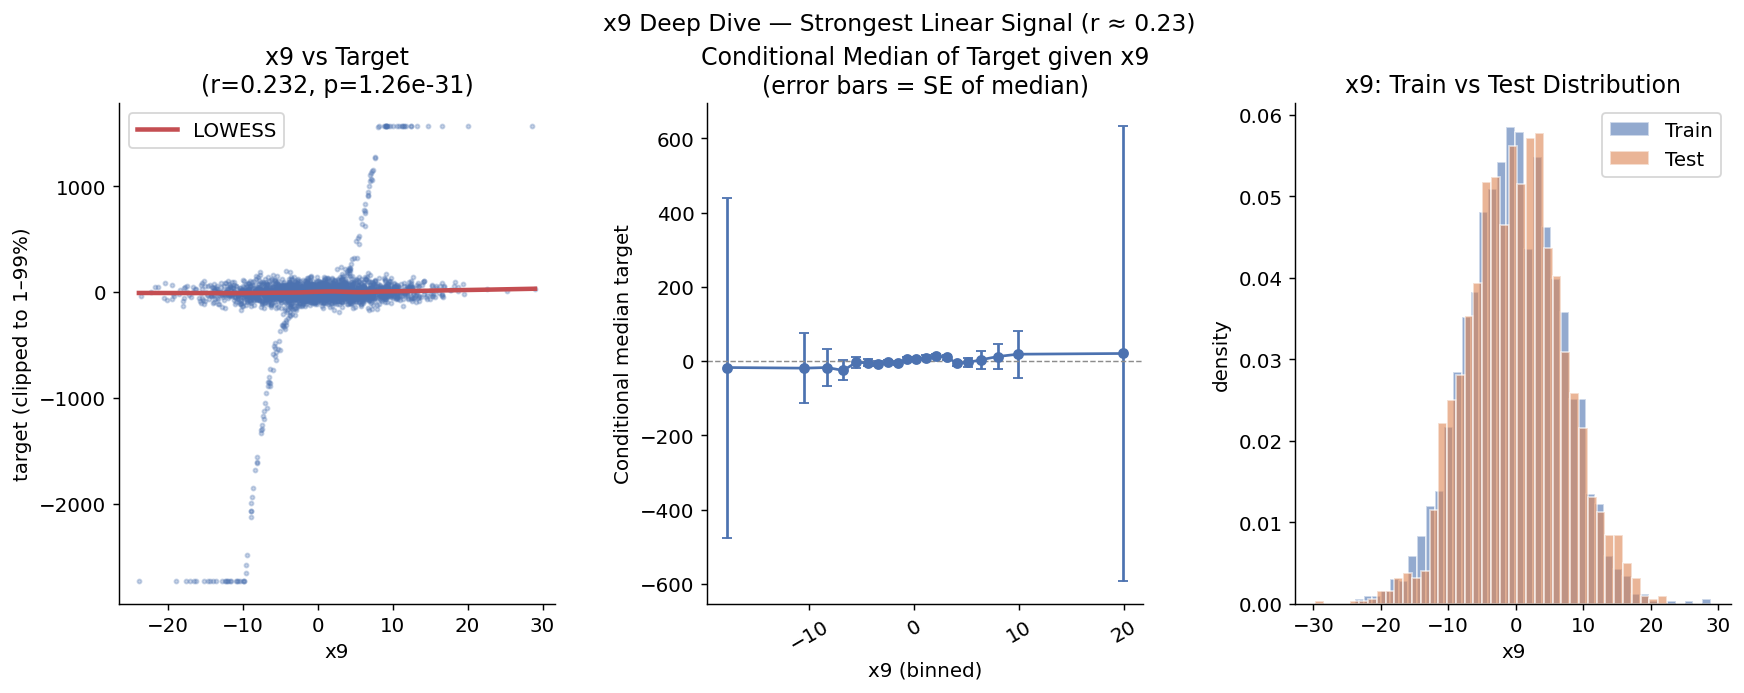

In [12]:
from scipy.stats import pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

x9    = X["x9"].dropna()
y_x9  = y.loc[x9.index]
y_cl  = y_x9.clip(y_x9.quantile(0.01), y_x9.quantile(0.99))

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- scatter with LOWESS ---
ax1 = fig.add_subplot(gs[0])
ax1.scatter(x9, y_cl, s=5, alpha=0.3, color=BLUE, rasterized=True)
smooth = lowess(y_cl, x9, frac=0.3, return_sorted=True)
ax1.plot(smooth[:, 0], smooth[:, 1], color=RED, lw=2.5, label="LOWESS")
r_val, p_val = pearsonr(x9, y_x9)
ax1.set_xlabel("x9")
ax1.set_ylabel("target (clipped to 1–99%)")
ax1.set_title(f"x9 vs Target\n(r={r_val:.3f}, p={p_val:.2e})")
ax1.legend()

# --- conditional median plot (binned x9) ---
ax2 = fig.add_subplot(gs[1])
n_bins = 20
x9_bins = pd.qcut(x9, q=n_bins, duplicates="drop")
cond = pd.DataFrame({"x9": x9.values, "target": y_x9.values, "bin": x9_bins.values})
cond_stats = cond.groupby("bin", observed=True)["target"].agg(["median", "std", "count"])
bin_centers = [iv.mid for iv in cond_stats.index]
ax2.errorbar(bin_centers, cond_stats["median"],
             yerr=cond_stats["std"] / np.sqrt(cond_stats["count"]),
             fmt="o-", color=BLUE, capsize=3, markersize=5)
ax2.axhline(0, color=GRAY, lw=0.8, linestyle="--")
ax2.set_xlabel("x9 (binned)")
ax2.set_ylabel("Conditional median target")
ax2.set_title("Conditional Median of Target given x9\n(error bars = SE of median)")
ax2.tick_params(axis="x", rotation=30)

# --- x9 distribution: train vs test ---
ax3 = fig.add_subplot(gs[2])
ax3.hist(x9, bins=40, alpha=0.6, color=BLUE,   label="Train", density=True, edgecolor="white")
ax3.hist(X_test["x9"].dropna(), bins=40, alpha=0.6, color=ORANGE,
         label="Test", density=True, edgecolor="white")
ax3.set_xlabel("x9")
ax3.set_ylabel("density")
ax3.set_title("x9: Train vs Test Distribution")
ax3.legend()

plt.suptitle("x9 Deep Dive — Strongest Linear Signal (r ≈ 0.23)", fontsize=13, y=1.02)
plt.show()

## 9 · Key Findings & Modelling Implications

| Finding | Implication |
|---|---|
| Target is extremely heavy-tailed (skew=13.6, kurtosis=708) | Evaluate models with and without outliers; consider Huber loss or log-transforming target |
| All features nearly uncorrelated with each other (max r≈0.06) | Features are mostly orthogonal — dimension reduction won't help much |
| x9 is the only meaningful linear predictor (r≈0.23) | Start with x9; all other features contribute marginally alone |
| Pairwise interaction products may carry more signal than raw features | Try polynomial features or tree-based models that capture interactions |
| Missing values (~1–2%) are scattered, low co-occurrence | Simple median imputation is safe; missingness pattern probably not informative |
| Extreme-target rows don't cluster separately in PCA space | Outliers aren't a cleanly separable subgroup — the signal is continuous, not bimodal |
| Train/test feature distributions look consistent (KS test) | No distribution shift — model trained on full train should generalize to test |